In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage des graphiques dans le notebook
%matplotlib inline

# Style des graphiques
sns.set(style="whitegrid")


In [2]:
# Chargement du fichier CSV
df = pd.read_csv(r"C:\Users\zizou\OneDrive\Desktop\stage 3ème\day 2\csvfiles\dataframefinale.csv",sep=";")

# Affichage des premières lignes
df


,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,01/07/2025,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0,1.500,62.0,7.60
1,01/07/2025,TN0008000739,"BTA 7,4% Fevrier 2030",291.0,0.300,183.0,7.50
2,01/07/2025,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.0,5.000,13.0,8.60
3,01/07/2025,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.0,1.000,7.0,8.60
4,01/07/2025,TN0008000606,"BTA 6,7% Avril 2028",5660.0,5.742,31.0,9.10
...,...,...,...,...,...,...,...
19924,31/12/2024,TN0008000812,"BTA 7,5% 13/12/2028",215.0,0.200,50.0,9.00
19925,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,5243.0,0.556,15.0,7.49
19926,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,28288.0,3.000,31.0,8.99
19927,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,48701.0,5.165,31.0,8.99


In [3]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,Nombre de Titres,Montant,Echéance,Taux
count,19929.00,19929.00,19929.00,19929.00
mean,8645.45,4.74,40.00,8.63
std,15259.20,6.97,60.58,0.80
min,86.00,0.08,3.00,6.69
25%,1073.00,1.00,10.00,8.03
50%,3131.00,2.00,20.00,8.97
75%,8748.00,5.50,32.00,9.01
max,89713.84,42.48,347.00,10.05


In [11]:
for col in colonnes_numeriques:
    print(f"\n📌 Colonne : {col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("Intervalle IQR (zone centrale) :", df[col].quantile(0.25), "→", df[col].quantile(0.75))
    print("Intervalle 80% des données :", df[col].quantile(0.10), "→", df[col].quantile(0.90))
    print("Intervalle 90% des données :", df[col].quantile(0.05), "→", df[col].quantile(0.95))
    print("Intervalle 98% des données :", df[col].quantile(0.01), "→", df[col].quantile(0.99))


📌 Colonne : Nombre de Titres
Min: 86.0
Max: 89713.84000000035
Intervalle IQR (zone centrale) : 1073.0 → 8748.0
Intervalle 80% des données : 496.8000000000002 → 20384.00000000001
Intervalle 90% des données : 280.0 → 40000.0
Intervalle 98% des données : 86.0 → 89653.9648000005

📌 Colonne : Montant
Min: 0.08
Max: 42.4758400000002
Intervalle IQR (zone centrale) : 1.0 → 5.5
Intervalle 80% des données : 0.46 → 10.351
Intervalle 90% des données : 0.2254000000000001 → 18.001
Intervalle 98% des données : 0.08 → 42.44116480000029

📌 Colonne : Echéance
Min: 3.0
Max: 347.0
Intervalle IQR (zone centrale) : 10.0 → 32.0
Intervalle 80% des données : 7.0 → 90.0
Intervalle 90% des données : 6.0 → 147.0
Intervalle 98% des données : 3.0 → 347.0

📌 Colonne : Taux
Min: 6.69
Max: 10.05
Intervalle IQR (zone centrale) : 8.03 → 9.01
Intervalle 80% des données : 7.26 → 9.47
Intervalle 90% des données : 7.25 → 9.89
Intervalle 98% des données : 6.69 → 10.05


In [5]:
# Filtrage des conditions
nb_titres_sup_400k = df[df["Nombre de Titres"] > 400000].shape[0]
taux_sup_15 = df[df["Taux"] > 15].shape[0]
nb_titres_inf_30 = df[df["Nombre de Titres"] < 30].shape[0]
Echéance_sup_200 = df[df["Echéance"] == 0].shape[0]
Montant_sup =df[df["Montant"] > 150].shape[0]


print(f"📦 Nombre de lignes avec Nombre de Titres > 400000 : {nb_titres_sup_400k}")
print(f"📈 Nombre de lignes avec Taux > 15 : {taux_sup_15}")
print(f"📦 Nombre de lignes avec Nombre de Titres < 30 : {nb_titres_inf_30}")
print(f" Nombre de lignes dont l'echeance est superieure a 200 : {Echéance_sup_200}")
print(f" Nombre de lignes dont le montant est superieur a 100 :{Montant_sup}")



📦 Nombre de lignes avec Nombre de Titres > 400000 : 0
📈 Nombre de lignes avec Taux > 15 : 0
📦 Nombre de lignes avec Nombre de Titres < 30 : 0
 Nombre de lignes dont l'echeance est superieure a 200 : 0
 Nombre de lignes dont le montant est superieur a 100 :0


In [6]:
# === Localiser le min et le max de chaque colonne numérique ===
colonnes_numeriques = df.select_dtypes(include='number').columns

for col in colonnes_numeriques:
    min_val = df[col].min()
    max_val = df[col].max()
    idx_min = df[col].idxmin()
    idx_max = df[col].idxmax()
    
    print(f"\n🔹 Feature : {col}")
    print(f"  ➤ Min : {min_val} (ligne {idx_min})")
    display(df.loc[[idx_min]])
    print(f"  ➤ Max : {max_val} (ligne {idx_max})")
    display(df.loc[[idx_max]])



🔹 Feature : Nombre de Titres
  ➤ Min : 86.0 (ligne 561)


,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
561,06/01/2025,TN0008000606,"BTA 6,7% Avril 2028",86.00,0.08,63.00,8.50


  ➤ Max : 89713.84000000035 (ligne 54)


,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
54,02/01/2025,TNX0K9990B08,EMP NAT 2024 T2 CB TF,89713.84,10.00,20.00,8.99



🔹 Feature : Montant
  ➤ Min : 0.08 (ligne 563)


...

,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
448,05/02/2025,TNHUVZNLATV4,BTA 8% 31 Janvier 2029,499.00,0.50,347.00,8.30



🔹 Feature : Taux
  ➤ Min : 6.69 (ligne 2843)


,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
2843,04/05/2021,TN0008000366,BTA 6% AVRIL 2024,3189.00,3.20,7.00,6.69


  ➤ Max : 10.05 (ligne 306)


,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
306,03/07/2025,TN7PM93UZP50,EMP NAT 2022 T4 CB TV,60000.00,6.00,134.00,10.05


In [7]:
print("\n📄 Infos sur le dataset :")
df.info()
print("\n📏 Dimensions :", df.shape)


📄 Infos sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19929 entries, 0 to 19928
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataloadingdate   19929 non-null  object 
 1   ISIN              19929 non-null  object 
 2   Libellé           19929 non-null  object 
 3   Nombre de Titres  19929 non-null  float64
 4   Montant           19929 non-null  float64
 5   Echéance          19929 non-null  float64
 6   Taux              19929 non-null  float64
dtypes: float64(4), object(3)
memory usage: 1.1+ MB

📏 Dimensions : (19929, 7)


In [13]:
colonnes_numeriques = df.select_dtypes(include=["int64", "float64"]).columns
outliers_counts = {}

for col in colonnes_numeriques:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_counts[col] = outliers.shape[0]

print("\n🚨 Nombre d'outliers par colonne numérique :")
for col, count in outliers_counts.items():
    print(f"{col}: {count} outliers")


🚨 Nombre d'outliers par colonne numérique :
Nombre de Titres: 2006 outliers
Montant: 1551 outliers
Echéance: 3028 outliers
Taux: 0 outliers


C:\Users\zizou\AppData\Local\Temp\ipykernel_22920\479471677.py:6: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


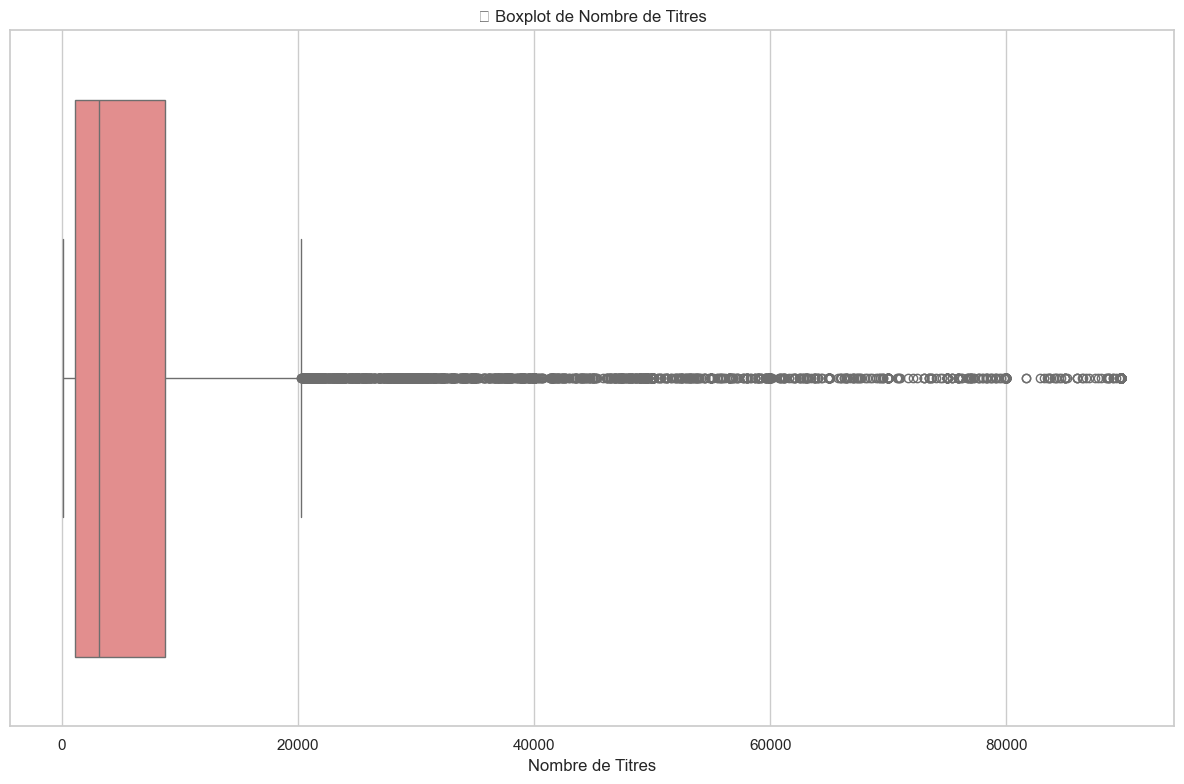

C:\Users\zizou\AppData\Local\Temp\ipykernel_22920\479471677.py:6: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


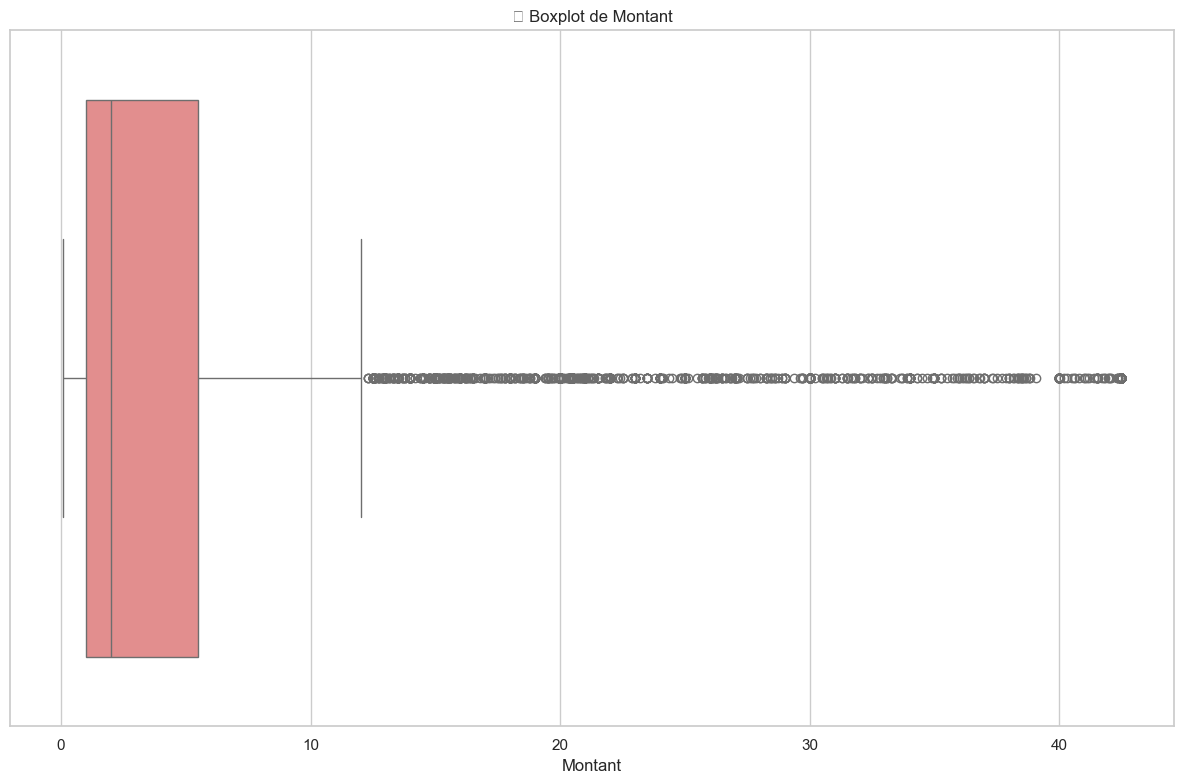

C:\Users\zizou\AppData\Local\Temp\ipykernel_22920\479471677.py:6: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


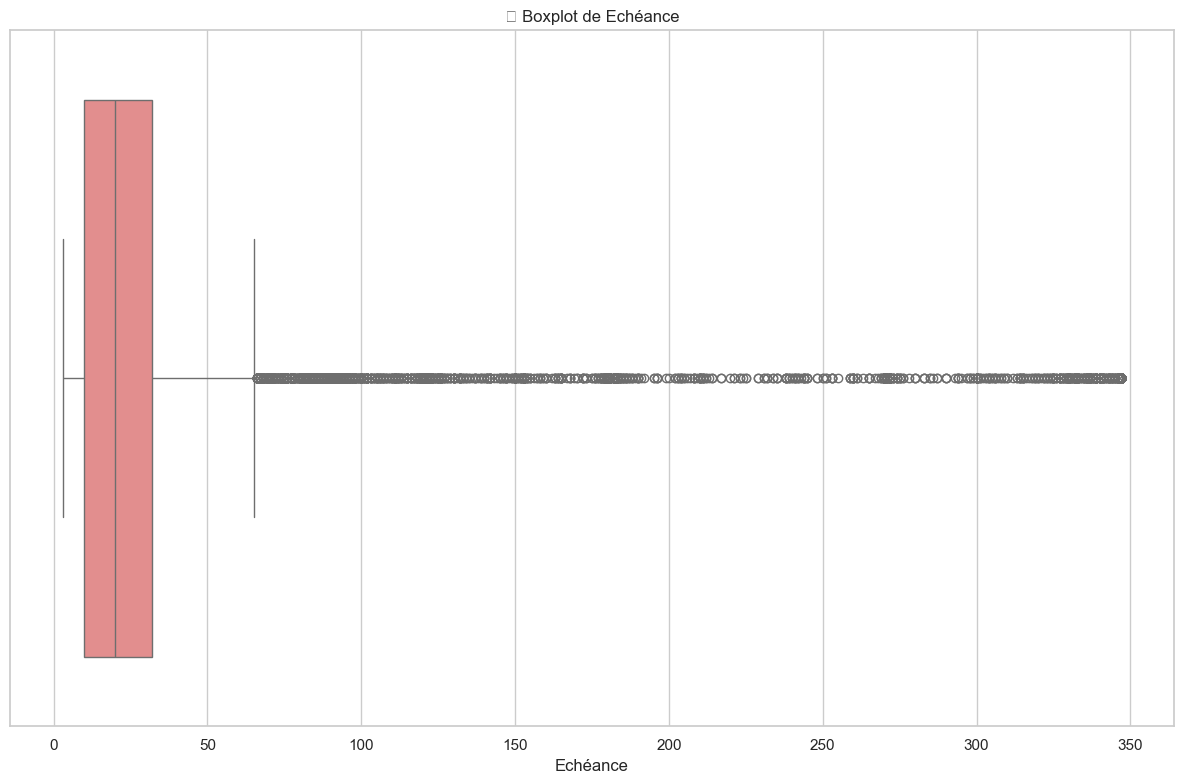

C:\Users\zizou\AppData\Local\Temp\ipykernel_22920\479471677.py:6: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


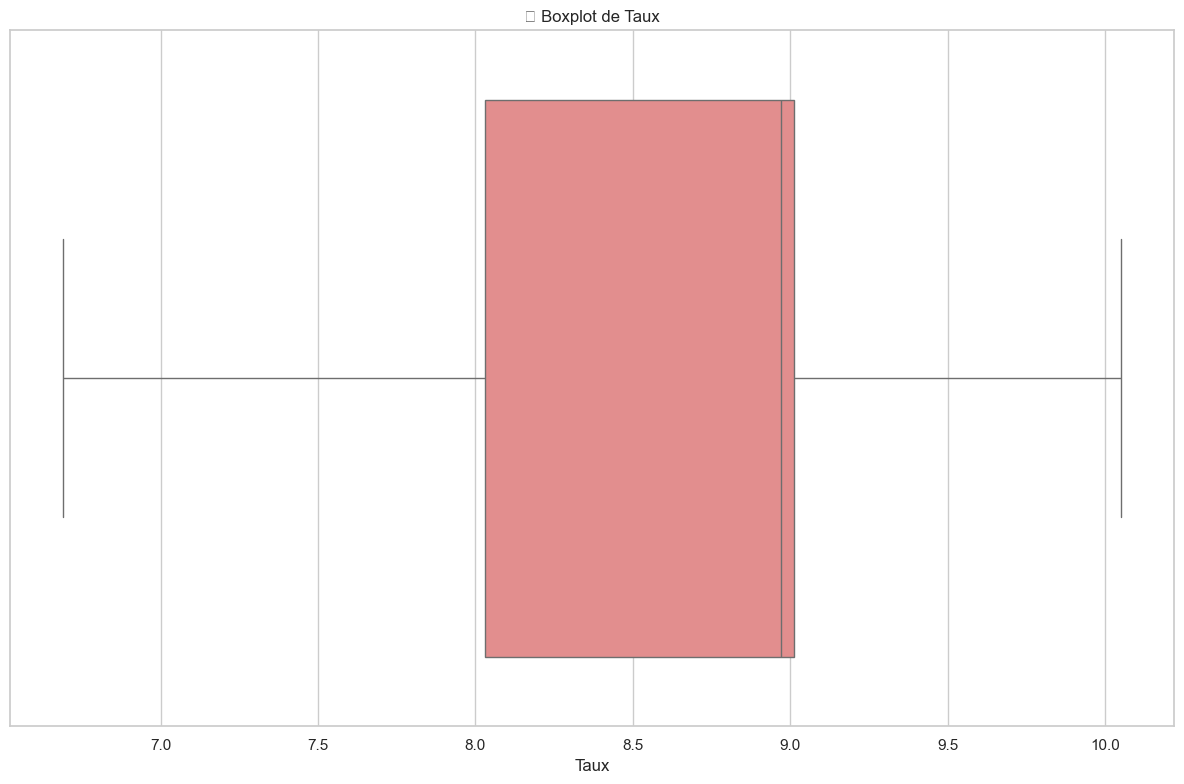

In [10]:
for col in colonnes_numeriques:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x=df[col], color="lightcoral")
    plt.title(f"📦 Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

C:\Users\zizou\AppData\Local\Temp\ipykernel_22920\2098685906.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


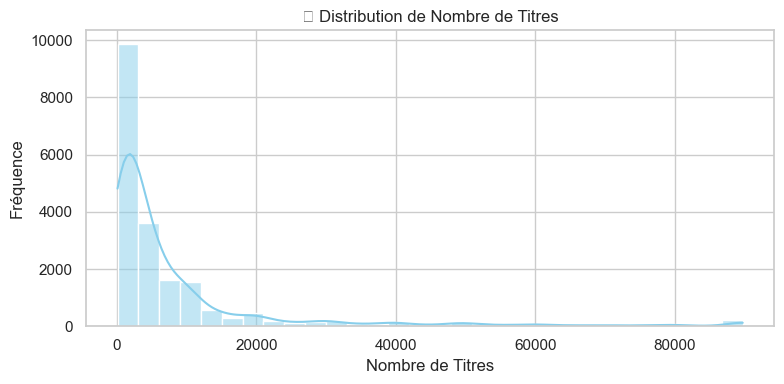

C:\Users\zizou\AppData\Local\Temp\ipykernel_22920\2098685906.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


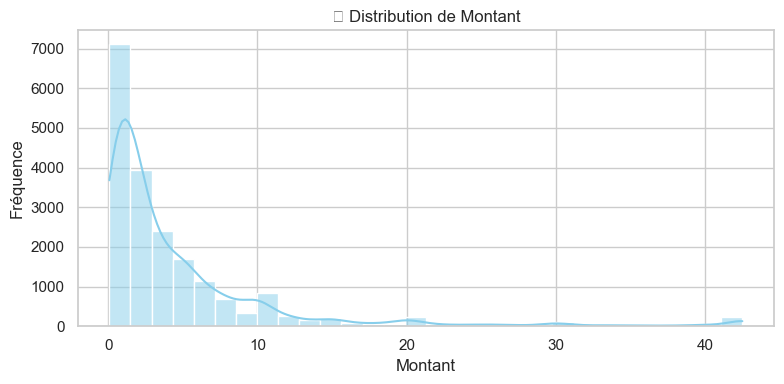

C:\Users\zizou\AppData\Local\Temp\ipykernel_22920\2098685906.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


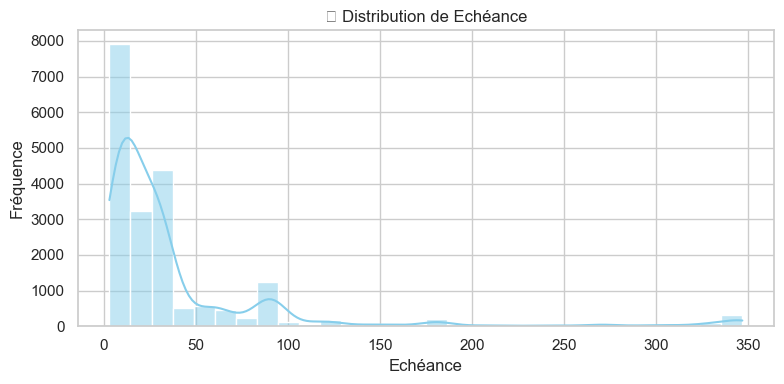

C:\Users\zizou\AppData\Local\Temp\ipykernel_22920\2098685906.py:7: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


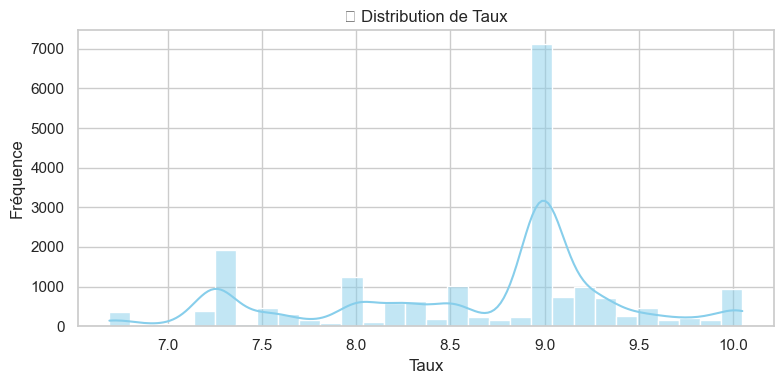

In [12]:
for col in colonnes_numeriques:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True, color="skyblue")
    plt.title(f"📈 Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.tight_layout()
    plt.show()

C:\Users\zizou\AppData\Local\Temp\ipykernel_17148\765395381.py:4: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


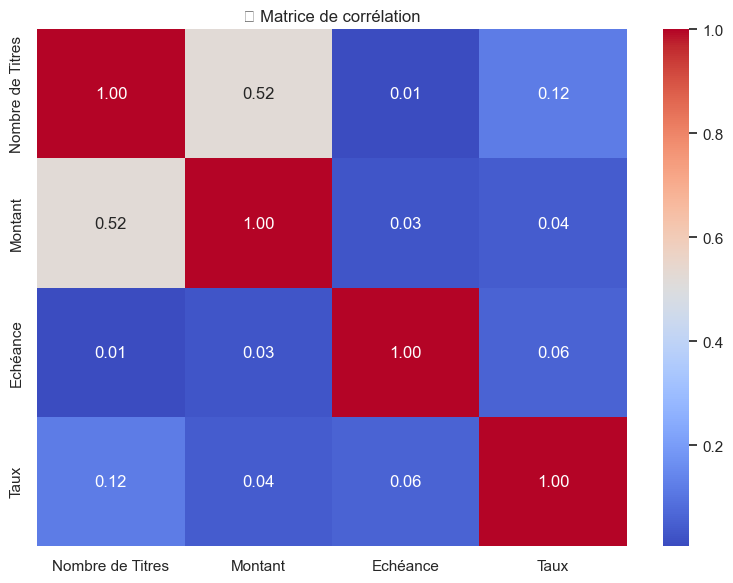

In [70]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[colonnes_numeriques].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("🔗 Matrice de corrélation")
plt.tight_layout()
plt.show()
